# Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import graphviz

from sklearn import tree
from sklearn.datasets import make_classification, load_iris, load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_graphviz
from sklearn.model_selection import train_test_split

%matplotlib inline

> **Nota aclaratoria:** La resolución y explicación de los ejercicios de este laboratorio han sido desarrolladas con la asistencia de Inteligencia Artificial, específicamente utilizando Google AI Studio y el modelo Gemini.

> **Algoritmo CART (classification and regresion tree)**
> **Se busca entrenar un modelo para categorizar la información encontrando la frontera de desición, permite tener una mejor interpretabilidad que las redes neuronales dado que se puede tener una represetancion grafica del proceso de desiscion secuencial.**
>
> **Dado un conjunto de caracteristicas se establece una condición que realiza una particion binaria de los datos a clasificar repitiendo hasta encontrar particiones lo más homogenea posible.**

**Intuición Visual de las Particiones Binarias**

A diferencia de los modelos lineales que trazan una única recta diagonal, el algoritmo CART divide el espacio realizando cortes ortogonales (perpendiculares a los ejes $x_1$ y $x_2$). Cada corte representa una "pregunta" o condición booleana (por ejemplo: ¿$x_1 \leq 1$?).

En el siguiente bloque, generaremos un conjunto sintético de 20 muestras y dibujaremos líneas manuales para visualizar cómo un par de condiciones simples pueden aislar grupos de datos (nodos puros).

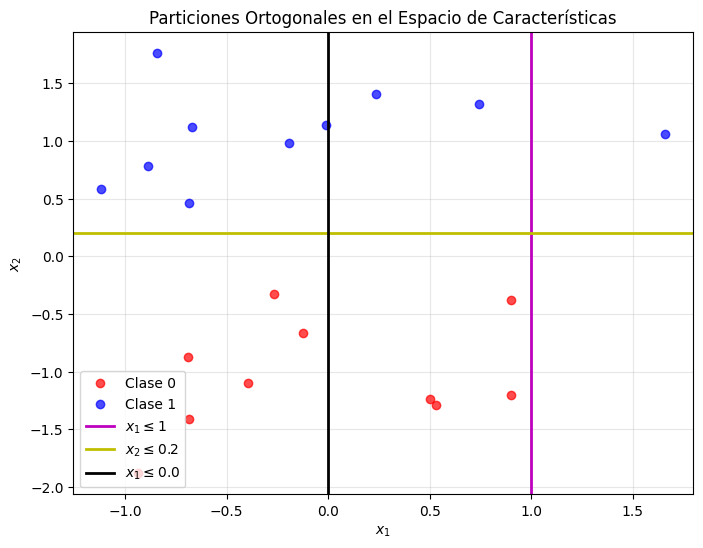

In [2]:
# Generación de datos sintéticos
X0, y0 = make_classification(n_samples=20, n_features=2, n_redundant=0,
                             n_informative=1, random_state=1, n_clusters_per_class=1)

# Preparación de la malla para visualización (opcional para contornos)
x = np.arange(-2, 3, 1)
x_, y_ = np.meshgrid(x, x)

fig, ax = plt.subplots(figsize=(8, 6))

# Graficamos las clases: 0 en rojo, 1 en azul
ax.plot(X0[:, 0][y0==0], X0[:, 1][y0==0], "ro", alpha=0.7, label="Clase 0")
ax.plot(X0[:, 0][y0==1], X0[:, 1][y0==1], "bo", alpha=0.7, label="Clase 1")

# Dibujamos divisiones manuales ortogonales (usando 'r' para raw strings)
ax.axvline(x=1.0, color='m', linestyle='-', linewidth=2, label=r"$x_1 \leq 1$")
ax.axhline(y=0.2, color='y', linestyle='-', linewidth=2, label=r"$x_2 \leq 0.2$")
ax.axvline(x=0.0, color='k', linestyle='-', linewidth=2, label=r"$x_1 \leq 0.0$")

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.title("Particiones Ortogonales en el Espacio de Características")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.show()

> **Gini index**
> $$G = 1 - (PC_1)^2 - (PC_2)^2$$
> **$PC_1$: Probablidad categoria 1**
> **$PC_2$: Probablidad categoria 2**
>
> **Si:**
> * **$G = 0$ nodos puros, datos que pertenecen a una sola categoría**
> * **Gini > 0 son nodos con impurezas, con mas de una categoría**
>
> **La funcion de coste, asocida al nodo padre:**
> $$J(k, t_k) = \frac{m_{left}}{m} G_{left} + \frac{m_{right}}{m} G_{right}$$

**La Matemática detrás de la Decisión (Impureza de Gini)**

El objetivo del algoritmo es encontrar el corte que genere subgrupos (nodos hijos) lo más "puros" posibles. La métrica utilizada en CART por defecto es el Índice de Gini.

Para un nodo que contiene proporciones $p_i$ de cada clase $i$, el índice de Gini se calcula como:
$$G = 1 - \sum_{i=1}^{n} p_i^2$$

Si un nodo contiene 6 puntos rojos y 0 azules, $p_{rojo} = 1.0$ y $p_{azul} = 0.0$:
$$G = 1 - (1.0)^2 - (0.0)^2 = 0$$
Un $G = 0$ indica que el nodo es perfectamente puro (no se requiere seguir dividiendo).

Para elegir cuál es el mejor corte (característica $k$ y umbral $t_k$), el algoritmo evalúa la **Función de Coste $J$**, que es una suma ponderada de las impurezas de los nodos hijos resultantes. El algoritmo seleccionará de manera codiciosa (*greedy*) el corte que minimice este coste $J$.

**Algoritmo**
>
> **1. Calcular todos los posibles condiciones.**
>
> **2. Calcular los indices de Gini.**
>
> **3. Encontrar la funcion de coste**
>
> **4. Escoger la menor funcion de coste**
>
> **5. Repetir.**

# Parte 2: Actividad

**Preparación y Entrenamiento del Modelo CART**

El algoritmo interno de Scikit-Learn (basado en CART) evaluará automáticamente todas las características ($x_i$) y todos los posibles umbrales de corte ($t_k$), calculando el Índice de Gini para cada combinación. Aquella que minimice la función de coste será seleccionada como la "raíz" o nodo principal, y el proceso se repetirá recursivamente para los nodos hijos.

Para ello, seguiremos el flujo estándar de Machine Learning:
1. Cargamos el **Dataset Iris** (que contiene 150 muestras de 3 especies de flores descritas por 4 características: longitud y ancho de sépalos y pétalos).
2. Dividimos los datos en conjuntos de entrenamiento y prueba usando `train_test_split` para evitar sesgos y poder evaluar el modelo con datos "nunca antes vistos".
3. Instanciamos el `DecisionTreeClassifier` y lo entrenamos con el método `.fit()`.

> **1. Importar iris dataset**


In [3]:
iris = load_iris()
X = iris.data
y = iris.target

> **2. Generar una intuición respecto a iris dataset. Ver laboratorio anterior.**

In [4]:
print(f"Dimensiones de X (Características): {X.shape}")
print(f"Dimensiones de y (Etiquetas): {y.shape}")
print(f"Clases a predecir: {iris.target_names}")
print(f"Características analizadas: {iris.feature_names}\n")

Dimensiones de X (Características): (150, 4)
Dimensiones de y (Etiquetas): (150,)
Clases a predecir: ['setosa' 'versicolor' 'virginica']
Características analizadas: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']



> **3. Dividir el dataset empleanto el metodo train_test_split de sklearn**


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño del set de entrenamiento: {len(X_train)}")
print(f"Tamaño del set de prueba: {len(X_test)}\n")

Tamaño del set de entrenamiento: 120
Tamaño del set de prueba: 30



> **4. Dentro de sklearn, aplicar el algoritmo DecisionTreeClassifier.**


In [6]:
# Fijamos random_state para que las particiones internas sean reproducibles
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Evaluamos rápidamente el desempeño
acc_train = clf.score(X_train, y_train)
acc_test = clf.score(X_test, y_test)

print(f"Precisión en entrenamiento: {acc_train * 100:.2f}%")
print(f"Precisión en prueba: {acc_test * 100:.2f}%")

Precisión en entrenamiento: 100.00%
Precisión en prueba: 100.00%


> **5. Para el clasificador analice el gráfico de desición:**

**Análisis e Interpretación del Árbol**

A continuación, generaremos un diagrama de flujo del modelo entrenado utilizando `plot_tree`. Para leer este gráfico, debemos entender la anatomía de sus nodos:
*   **Nodo raíz (Root):** Es el primer bloque en la parte superior. Representa la característica que generó la mejor división inicial del conjunto de datos (la mayor reducción de impureza de Gini).
*   **Condición (ej. $x \leq 2.45$):** Es la regla de partición. Si una muestra cumple la condición, viaja por la rama izquierda (`True`); si no, viaja por la rama derecha (`False`).
*   **Samples:** Indica cuántas muestras del conjunto de entrenamiento cayeron en ese nodo.
*   **Value:** Muestra la distribución de las clases en ese nodo (ej. `[40, 40, 40]` significa 40 Setosas, 40 Versicolor y 40 Virginicas).
*   **Class:** Indica la clase mayoritaria que el modelo predeciría si la ejecución se detuviera en ese nodo.
*   **Nodos hoja (Leaves):** Son los bloques finales que no tienen divisiones adicionales. Al no aplicar poda (*pruning*), todos nuestros nodos hoja tendrán un Gini de $0.0$ (nodos 100% puros).

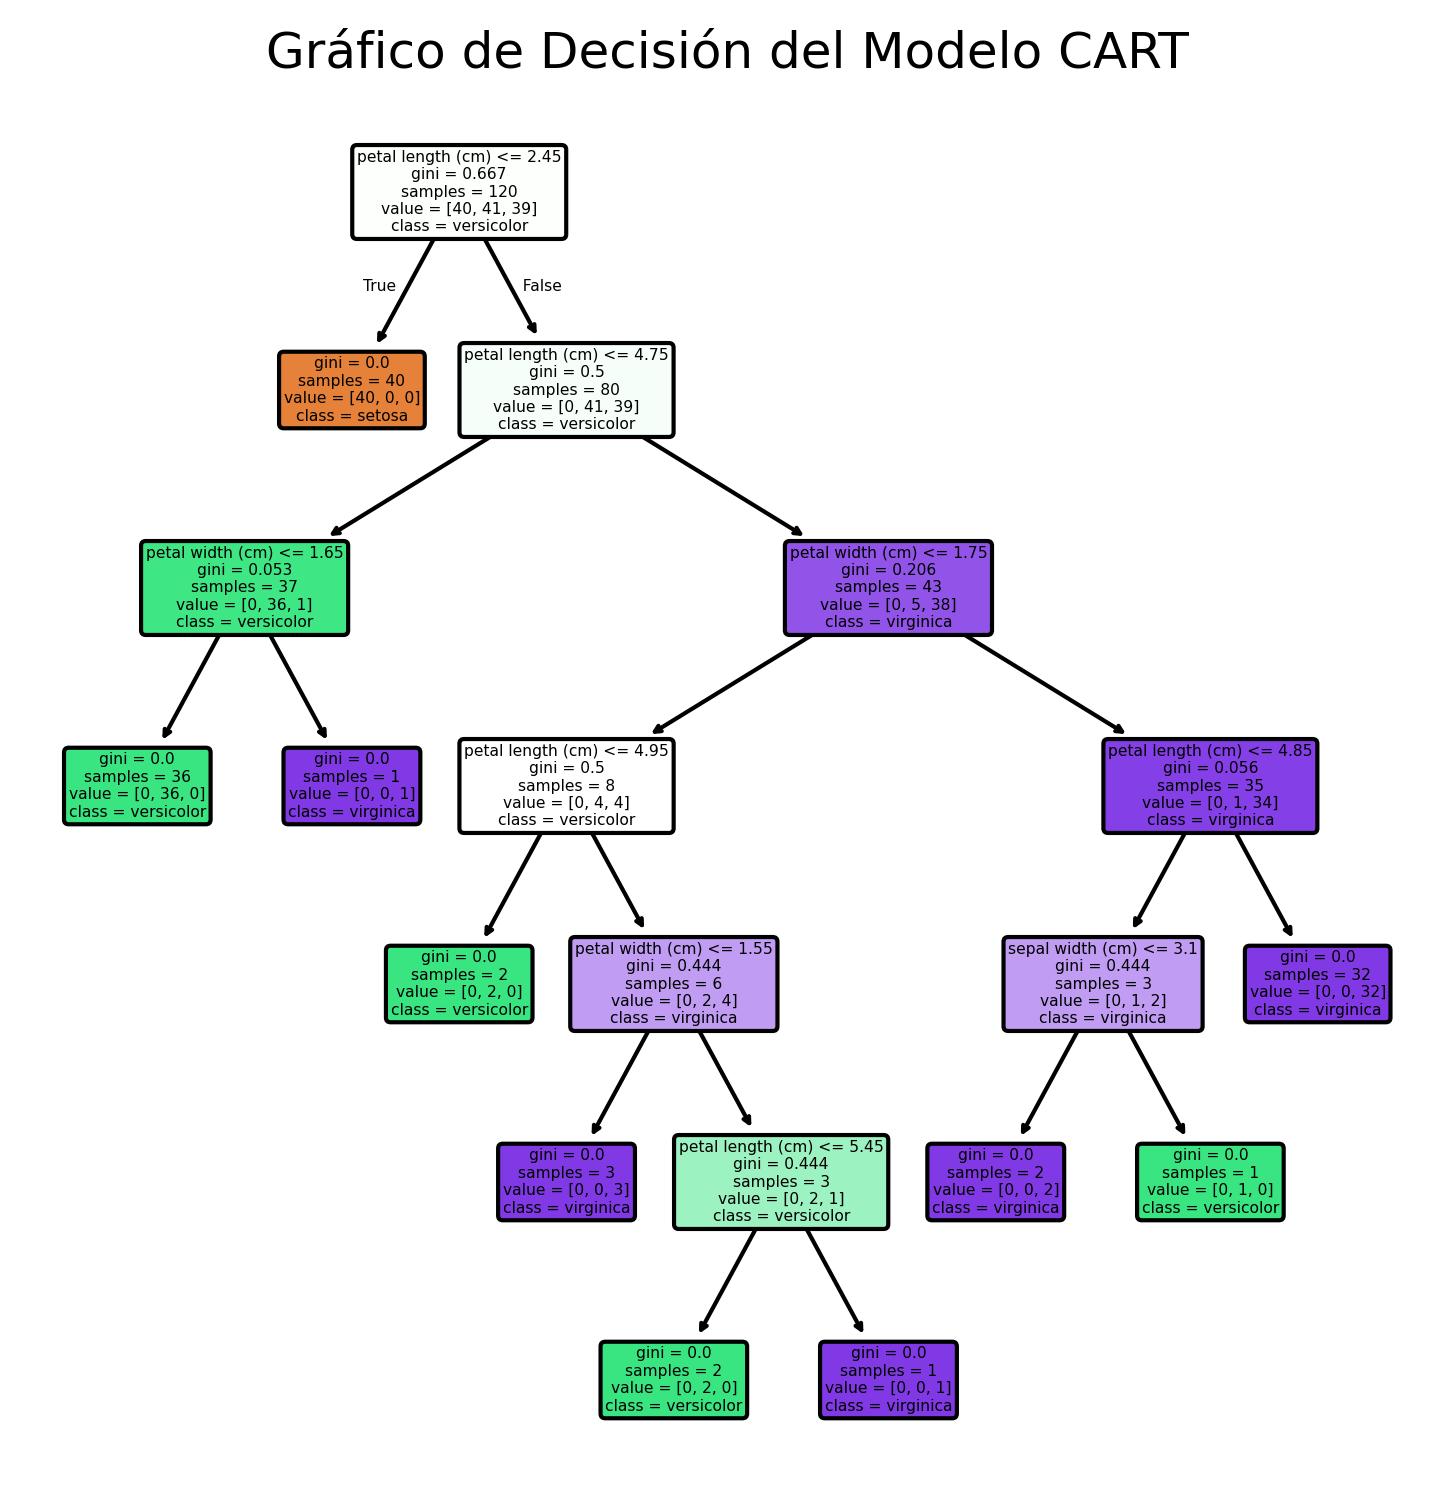

In [7]:
# Configuramos el tamaño y la resolución del gráfico
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 6), dpi=300)

# Generamos el gráfico del árbol
# Nota: Cambiamos impurity=True para poder observar el valor de Gini en cada nodo
graph = tree.plot_tree(clf,
                       class_names=iris.target_names,
                       feature_names=iris.feature_names,
                       impurity=True,
                       filled=True,
                       rounded=True,
                       ax=axes)

plt.title("Gráfico de Decisión del Modelo CART")
plt.show()

> **6. Características importantes.**

**Importancia de las Características (Feature Importance)**

En los algoritmos basados en árboles (CART), la "importancia" de una característica se calcula observando cuánto reduce esa variable la impureza (Índice de Gini) en todos los nodos donde fue utilizada para realizar un corte. Esta reducción se pondera por la cantidad de muestras que pasaron por esos nodos.

El resultado es un valor entre 0 y 1 para cada característica. La suma de todas las importancias es igual a 1.

* Si una característica tiene una importancia de $0.0$, significa que el árbol no la utilizó en ninguna de sus reglas de decisión.
* Si tiene un valor alto, significa que los cortes realizados con esa variable lograron separar grandes volúmenes de datos en grupos muy puros.

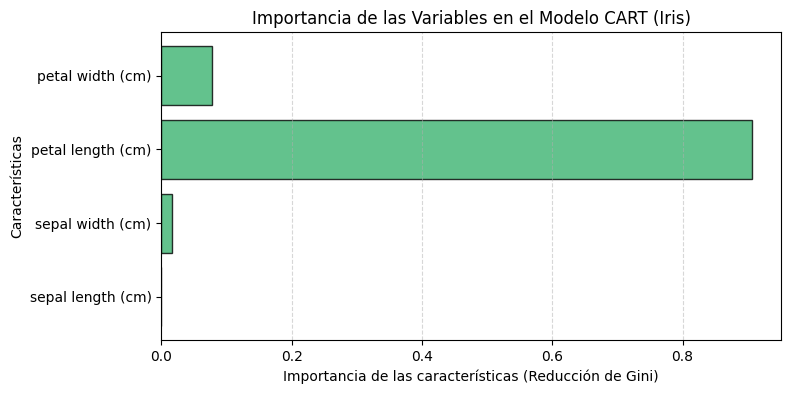

In [8]:
# Obtenemos las importancias calculadas internamente por el modelo
importancias = clf.feature_importances_

# Número total de características (en este caso 4)
caract = iris.data.shape[1]

# Visualización mediante un gráfico de barras horizontales
plt.figure(figsize=(8, 4))
plt.barh(range(caract), importancias, color='mediumseagreen', edgecolor='black', alpha=0.8)
plt.yticks(np.arange(caract), iris.feature_names)
plt.xlabel('Importancia de las características (Reducción de Gini)')
plt.ylabel('Características')
plt.title('Importancia de las Variables en el Modelo CART (Iris)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

> **7. Fronteras de desición.**

**Geometría de las Decisiones (Regiones Rectangulares)**

Como observamos en la Fase 1, los árboles de decisión (algoritmo CART) dividen el espacio de forma **ortogonal** (paralela a los ejes). Al combinar múltiples decisiones, el espacio de características termina dividiéndose en un conjunto de regiones hiper-rectangulares.

En el siguiente bloque, proporcionado en la guía del laboratorio, realizaremos el siguiente proceso:
1. Iteraremos sobre los 6 pares posibles de características que se pueden formar con las 4 variables del dataset Iris (ej. Sépalos vs Pétalos, Longitud vs Ancho).
2. Para cada par, entrenaremos un nuevo Árbol de Decisión usando únicamente esas dos variables.
3. Crearemos una "malla" de puntos y haremos que el modelo prediga a qué clase pertenece cada punto, dibujando superficies de colores.
4. Sobrepondremos los puntos reales del dataset para ver cómo la geometría de las regiones rectangulares intenta agruparlos.

*Nota: Hemos añadido una configuración de `figsize` para que el panel de 6 gráficos (2x3) se visualice correctamente sin amontonarse.*

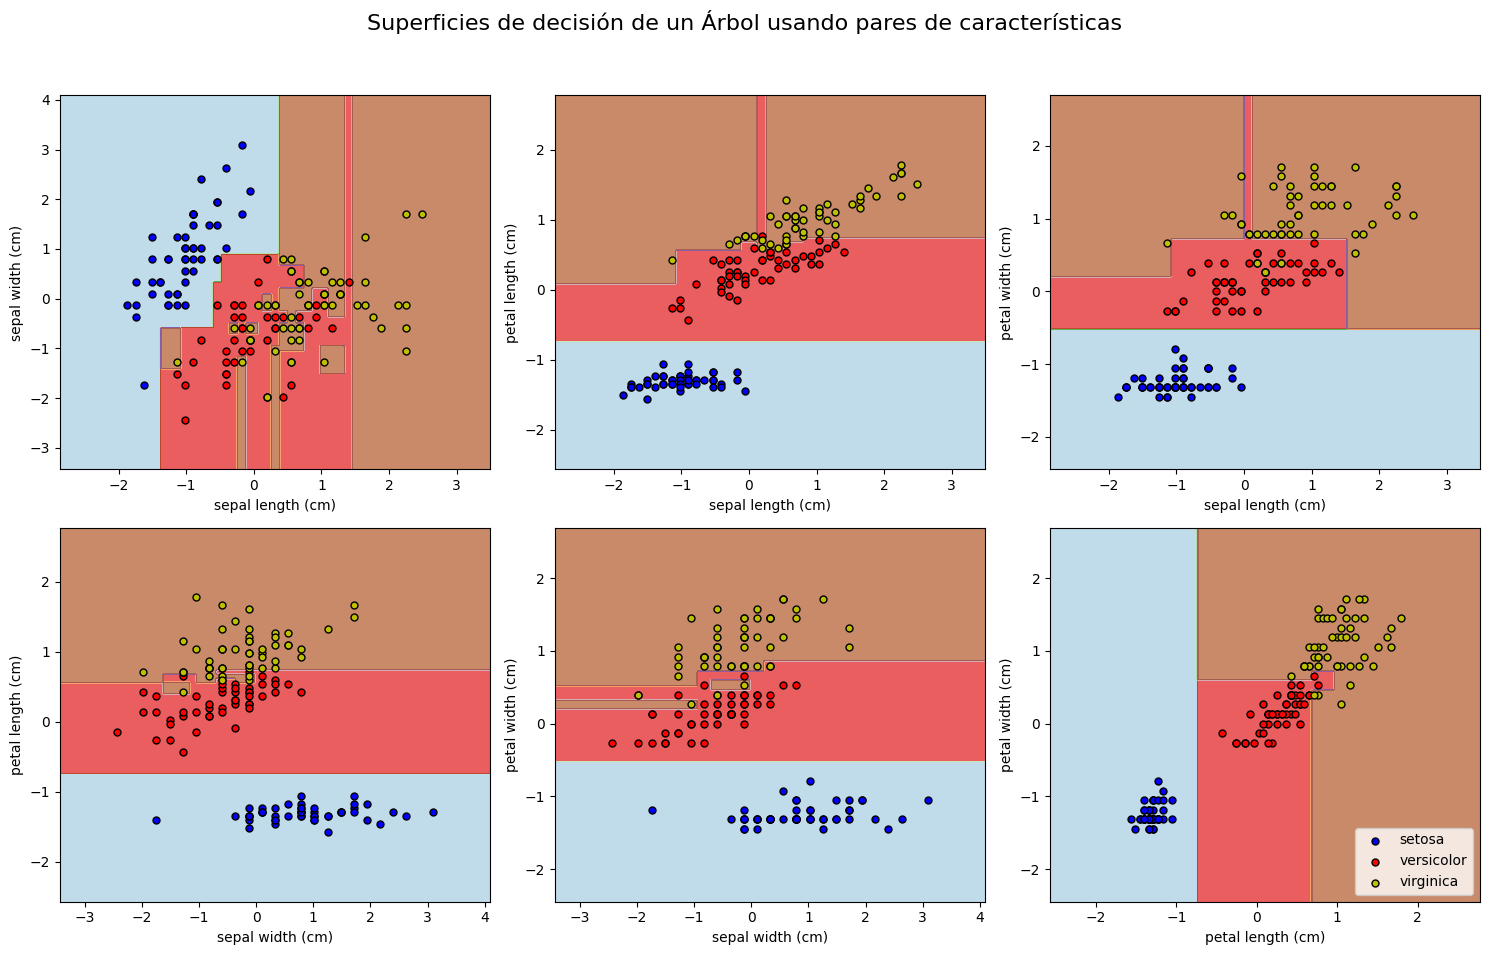

In [9]:
# Parámetros visuales y de clases
n_classes = 3
plot_colors = "bry" # Blue (Azul), Red (Rojo), Yellow (Amarillo)
plot_step = 0.02

# Configuramos un tamaño de figura amplio para una cuadrícula 2x3
plt.figure(figsize=(15, 10))

# Iteramos sobre todas las combinaciones posibles de a dos características
for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3],[1, 2], [1, 3], [2, 3]]):

    # 1. Extraemos solo las dos características correspondientes al par actual
    X = iris.data[:, pair]
    y = iris.target

    # 2. Barajamos los datos (Shuffle) para evitar sesgos en el orden
    idx = np.arange(X.shape[0])
    np.random.seed(13)
    np.random.shuffle(idx)
    X = X[idx]
    y = y[idx]

    # 3. Estandarización de las variables (Z-score)
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    X = (X - mean) / std

    # 4. Entrenamiento del modelo para este par específico
    clf_pair = DecisionTreeClassifier(random_state=42).fit(X, y)

    # 5. Configuración del subgráfico (2 filas, 3 columnas)
    plt.subplot(2, 3, pairidx + 1)

    # Límites para la malla basándonos en los mínimos y máximos de las variables
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Creación de la malla (meshgrid)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))

    # 6. Predicción sobre todos los puntos de la malla para dibujar las regiones
    Z = clf_pair.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Dibujamos las regiones coloreadas
    cs = plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.7)

    plt.xlabel(iris.feature_names[pair[0]])
    plt.ylabel(iris.feature_names[pair[1]])
    plt.axis("tight")

    # 7. Superposición de los puntos reales de entrenamiento
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i)
        plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i],
                    edgecolor='black', s=25)

plt.suptitle("Superficies de decisión de un Árbol usando pares de características", fontsize=16)
plt.legend(loc='lower right', bbox_to_anchor=(1.0, 0.0))
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()